# WADI CCF & Granger Causality Analysis

**Goal:** Build a statistically rigorous sensor-pair edge list from the WADI water-distribution dataset by combining cross-correlation function (CCF) analysis with Granger causality testing.

**Pipeline summary:**
1. Load & parse data → identify sensor columns  
2. Validate stationarity (ADF + KPSS) → apply first-differencing where required  
3. Compute baseline CCF for every sensor pair on normal days  
4. Quantify natural CCF variance across individual normal days  
5. **Q1** — Does CCF structure shift during attack windows?  
6. **Q2 setup** — Which pairs are ambiguous under CCF alone?  
7. **Q2** — Do Granger tests resolve ambiguous pairs into directed edges?  
8. Synthesise Q1 + Q2 → final strong-edge list  
9. Research-question summary table

---
## Setup & Imports

In [1]:
import subprocess
subprocess.run(
    ["pip", "install", "-q",
     "pandas", "numpy", "scipy", "statsmodels",
     "polars", "matplotlib", "seaborn", "tqdm", "joblib"],
    check=False
)

You should consider upgrading via the '/users/PAS1266/ralston168/WaDi/bin/python3 -m pip install --upgrade pip' command.


CompletedProcess(args=['pip', 'install', '-q', 'pandas', 'numpy', 'scipy', 'statsmodels', 'polars', 'matplotlib', 'seaborn', 'tqdm'], returncode=0)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pickle
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import correlate as sp_correlate, detrend
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from tqdm import tqdm

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (12, 5)})

print(f"polars      {pl.__version__}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")

polars      1.36.1
pandas      2.3.3
numpy       2.0.2


In [3]:
# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR          = Path("../../data/preprocess")
NORMAL_CSV        = DATA_DIR / "WADI_normal.csv"
ATTACK_CSV        = DATA_DIR / "WADI_attack.csv"
DICT_PATH         = Path("data_dict.csv")
BASELINE_CCF_PKL  = Path("baseline_ccf.pkl")
EDGES_CSV         = Path("wadi_edges.csv")

# ── Analysis constants ────────────────────────────────────────────────────────
CCF_MAX_LAG        = 10_800   # seconds (3-hour lag window)
SIGNIFICANCE_ALPHA = 0.05
NORMAL_VAR_MULT    = 1.0      # multiplier on normal-day std for deviation threshold
BASELINE_SUBSAMPLE = 100_000  # rows used for baseline CCF per pair (None = all rows)
GRANGER_MAX_LAG    = 20       # cap on VAR lag order for Granger tests
GRANGER_RESAMPLE_SECS = 60    # downsample factor before Granger (seconds per bin)
GRANGER_LAG        = 60       # lag in resampled bins (60 × 60s = 1-hour lookback)
GRANGER_SUBSAMPLE  = 20_000   # rows used per pair for Granger (None = all)
TIMESTAMP_FMT      = "%Y-%m-%dT%H:%M:%S%.f"

# Non-sensor metadata columns present in either CSV
META_COLS = {"sys_unk", "Date", "Time", "timestamp", "attack_label",
             "plant_run_status", "required_flow", "Row", "row"}

print("Constants loaded.")
print(f"  CCF_MAX_LAG           = {CCF_MAX_LAG:,} s")
print(f"  SIGNIFICANCE_ALPHA    = {SIGNIFICANCE_ALPHA}")
print(f"  BASELINE_SUBSAMPLE    = {BASELINE_SUBSAMPLE:,} rows")
print(f"  GRANGER_RESAMPLE_SECS = {GRANGER_RESAMPLE_SECS} s  (1-min bins)")
print(f"  GRANGER_LAG           = {GRANGER_LAG} bins  ({GRANGER_LAG * GRANGER_RESAMPLE_SECS // 60} min lookback)")

Constants loaded.
  CCF_MAX_LAG        = 10,800 s
  SIGNIFICANCE_ALPHA = 0.05
  BASELINE_SUBSAMPLE = 100,000 rows


---
## Section 1 — Data Loading

**Research question:** What sensors are available, and are they complete enough for time-series analysis?

We load both CSVs into Polars, parse timestamps, sort chronologically, and separate sensor columns from metadata. The `data_dict.csv` maps raw tag names to short names and classifies each signal as continuous, binary, or status — we iterate only over continuous sensors.

In [4]:
# ── Data dictionary ───────────────────────────────────────────────────────────
data_dict = pl.read_csv(DICT_PATH)
print(f"Data dictionary: {data_dict.shape[0]} entries, columns: {data_dict.columns}")

sensor_cols_from_dict = (
    data_dict
    .filter(pl.col("kind") == "continuous")
    .filter(pl.col("short_name").is_not_null())
    ["short_name"]
    .to_list()
)
print(f"Continuous sensors in data dict: {len(sensor_cols_from_dict)}")

Data dictionary: 124 entries, columns: ['column', 'zone', 'stage', 'stage_name', 'tag', 'instrument_type', 'full_name', 'signal_type', 'role', 'kind', 'units', 'min_normal', 'max_normal', 'mean_normal', 'short_name', 'description']
Continuous sensors in data dict: 68


In [5]:
# ── Load CSVs ─────────────────────────────────────────────────────────────────
print("Loading normal days …")
df_normal = pl.read_csv(NORMAL_CSV, infer_schema_length=10_000)
print(f"  shape : {df_normal.shape}")

print("Loading attack days …")
df_attack = pl.read_csv(ATTACK_CSV, infer_schema_length=10_000)
print(f"  shape : {df_attack.shape}")

# ── Column inventory ──────────────────────────────────────────────────────────
print(f"\nNormal CSV — {df_normal.width} columns")
for col, dtype in zip(df_normal.columns, df_normal.dtypes):
    tag = "[META]" if col in META_COLS else "[SENS]"
    print(f"  {tag}  {col:<45}  {dtype}")

Loading normal days …
  shape : (784571, 127)
Loading attack days …
  shape : (172801, 128)

Normal CSV — 127 columns
  [META]  sys_unk                                        Int64
  [META]  Date                                           String
  [META]  Time                                           String
  [SENS]  primary_quality_sensor_1                       Float64
  [SENS]  primary_quality_sensor_2                       Float64
  [SENS]  primary_quality_sensor_3                       Float64
  [SENS]  primary_quality_sensor_4                       Float64
  [SENS]  primary_quality_sensor_5                       Float64
  [SENS]  primary_flow_sensor                            Float64
  [SENS]  primary_level_sw_alarm_lo_1                    Int64
  [SENS]  primary_level_sw_alarm_lo_2                    Int64
  [SENS]  primary_level_sensor                           Float64
  [SENS]  primary_valve_status_1                         Int64
  [SENS]  primary_valve_status_2               

In [6]:
# ── Parse timestamps and sort ─────────────────────────────────────────────────
df_normal = (
    df_normal
    .with_columns(pl.col("timestamp").str.to_datetime(TIMESTAMP_FMT))
    .sort("timestamp")
)

df_attack = (
    df_attack
    .with_columns(pl.col("timestamp").str.to_datetime(TIMESTAMP_FMT))
    .sort("timestamp")
)

print(f"Normal  time range: {df_normal['timestamp'].min()}  →  {df_normal['timestamp'].max()}")
print(f"Attack  time range: {df_attack['timestamp'].min()}  →  {df_attack['timestamp'].max()}")

# ── Identify sensor columns present in the CSVs ───────────────────────────────
sensor_cols = [c for c in sensor_cols_from_dict if c in df_normal.columns]
meta_in_normal = [c for c in df_normal.columns if c not in sensor_cols]

print(f"\nSensor columns in normal CSV : {len(sensor_cols)}")
print(f"Metadata columns             : {meta_in_normal}")
print(f"\nFirst 5 sensor names: {sensor_cols[:5]}")

Normal  time range: 2017-09-25 00:00:00  →  2017-10-07 00:59:59
Attack  time range: 2017-10-09 00:00:00  →  2017-10-11 00:59:59

Sensor columns in normal CSV : 68
Metadata columns             : ['Date', 'Time', 'primary_level_sw_alarm_lo_1', 'primary_level_sw_alarm_lo_2', 'primary_valve_status_1', 'primary_valve_status_2', 'primary_valve_status_3', 'primary_valve_status_4', 'primary_pump_status_1', 'primary_pump_status_2', 'primary_pump_status_3', 'primary_pump_status_4', 'primary_pump_status_5', 'primary_pump_status_6', 'consumer_level_sw_alarm_hi_101', 'consumer_level_sw_alarm_lo_101', 'consumer_level_sw_alarm_hi_201', 'consumer_level_sw_alarm_lo_201', 'consumer_level_sw_alarm_hi_301', 'consumer_level_sw_alarm_lo_301', 'consumer_level_sw_alarm_hi_401', 'consumer_level_sw_alarm_lo_401', 'consumer_level_sw_alarm_hi_501', 'consumer_level_sw_alarm_lo_501', 'consumer_level_sw_alarm_hi_601', 'consumer_level_sw_alarm_lo_601', 'elevated_valve_output', 'elevated_valve_status_1', 'elevated_val

**What to look for:** Confirm all expected sensor columns loaded. Check timestamp range covers 11–14 normal days and ~2 attack days. Missing sensors may require adjusting the data-dict `kind` filter.

---
## Section 2 — Stationarity Validation

**Research question:** Which sensors carry a unit root or deterministic trend that would inflate CCF estimates if left uncorrected?

We run two complementary tests on normal-day data:
- **ADF** (Augmented Dickey–Fuller): H₀ = unit root; reject H₀ (p < α) → stationary.
- **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin): H₀ = stationary; reject H₀ (p < α) → non-stationary.

Each sensor is assigned to one of three groups based on the joint test outcome:

| Group | ADF p | KPSS p | Interpretation | Transform |
|-------|-------|--------|----------------|-----------|
| 1 | > α | < α | Both agree: non-stationary | First-difference |
| 2 | < α | > α | Both agree: stationary | Use as-is |
| 3 | < α | < α | Conflict: trend-stationary | Linear detrend |

**Pairwise compatibility rule** (applied in every CCF and Granger computation): if either sensor in a pair is Group 1, both series are first-differenced before analysis — mixing levels and differences in a bivariate VAR is invalid. Group 1 differencing takes precedence over Group 3 detrending when the two sensors are from different groups.

In [7]:
# ── Run ADF + KPSS on a contiguous window (10K rows) ─────────────────────────
STAT_N = 10_000
df_stat_pd = df_normal.head(STAT_N).select(sensor_cols).to_pandas()

def classify_stationarity_group(adf_p, kpss_p, alpha=SIGNIFICANCE_ALPHA):
    """
    Group 1 — ADF p > α, KPSS p < α : both tests say non-stationary → first-difference
    Group 2 — ADF p < α, KPSS p > α : both tests say stationary    → use as-is
    Group 3 — ADF p < α, KPSS p < α : conflict (trend-stationary)  → linear detrend
    Group 1 also used for the 4th combination (ADF non-stat, KPSS stat) as a
    conservative fall-through.
    """
    if adf_p is None or kpss_p is None:
        return 2  # no data → treat as stationary
    if adf_p > alpha and kpss_p < alpha:
        return 1  # both agree: non-stationary
    elif adf_p <= alpha and kpss_p >= alpha:
        return 2  # both agree: stationary
    elif adf_p <= alpha and kpss_p < alpha:
        return 3  # conflict: trend-stationary
    else:          # adf_p > alpha and kpss_p >= alpha — ADF: non-stat, KPSS: stat
        return 1  # conservative: difference

stat_rows = []
for sensor in tqdm(sensor_cols, desc="Stationarity tests"):
    series = df_stat_pd[sensor].dropna().values
    if len(series) < 100 or series.std() < 1e-9:
        stat_rows.append({
            "sensor": sensor, "adf_statistic": None, "adf_pvalue": None,
            "adf_stationary": None, "kpss_statistic": None, "kpss_pvalue": None,
            "kpss_stationary": None, "stationarity_group": 2,
        })
        continue

    # ADF
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    adf_stationary = bool(adf_p < SIGNIFICANCE_ALPHA)

    # KPSS
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
        kpss_stationary = bool(kpss_p >= SIGNIFICANCE_ALPHA)
    except Exception:
        kpss_stat, kpss_p, kpss_stationary = None, None, True

    group = classify_stationarity_group(
        float(adf_p),
        float(kpss_p) if kpss_p is not None else None,
    )

    stat_rows.append({
        "sensor":             sensor,
        "adf_statistic":      round(float(adf_stat), 4),
        "adf_pvalue":         round(float(adf_p), 4),
        "adf_stationary":     adf_stationary,
        "kpss_statistic":     round(float(kpss_stat), 4) if kpss_stat is not None else None,
        "kpss_pvalue":        round(float(kpss_p), 4) if kpss_p is not None else None,
        "kpss_stationary":    kpss_stationary,
        "stationarity_group": group,
    })

stationarity_df = pl.DataFrame(stat_rows)
print(stationarity_df)

Stationarity tests:   0%|          | 0/68 [00:00<?, ?it/s]/tmp/ipykernel_2398657/4059043954.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
Stationarity tests:   1%|▏         | 1/68 [00:04<04:29,  4.02s/it]/tmp/ipykernel_2398657/4059043954.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
Stationarity tests:   3%|▎         | 2/68 [00:07<04:00,  3.65s/it]/tmp/ipykernel_2398657/4059043954.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regressio

shape: (68, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ sensor     ┆ adf_statis ┆ adf_pvalue ┆ adf_stati ┆ kpss_stat ┆ kpss_pval ┆ kpss_stat ┆ stationar │
│ ---        ┆ tic        ┆ ---        ┆ onary     ┆ istic     ┆ ue        ┆ ionary    ┆ ity_group │
│ str        ┆ ---        ┆ f64        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆ f64        ┆            ┆ bool      ┆ f64       ┆ f64       ┆ bool      ┆ i64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ sys_unk    ┆ -22.1597   ┆ 0.0        ┆ true      ┆ 11.659    ┆ 0.01      ┆ false     ┆ 3         │
│ primary_qu ┆ -1.2026    ┆ 0.6725     ┆ false     ┆ 3.3126    ┆ 0.01      ┆ false     ┆ 1         │
│ ality_sens ┆            ┆            ┆           ┆           ┆           ┆           ┆           │
│ or_1       ┆            ┆            ┆           ┆           ┆           ┆

In [8]:
# ── Group membership lookup ────────────────────────────────────────────────────
sensor_groups: dict[str, int] = {
    row["sensor"]: row["stationarity_group"]
    for row in stationarity_df.iter_rows(named=True)
}

g1_sensors = [s for s, g in sensor_groups.items() if g == 1]
g2_sensors = [s for s, g in sensor_groups.items() if g == 2]
g3_sensors = [s for s, g in sensor_groups.items() if g == 3]

print(f"Group 1 (difference)  : {len(g1_sensors)} sensors")
print(f"Group 2 (as-is)       : {len(g2_sensors)} sensors")
print(f"Group 3 (detrend)     : {len(g3_sensors)} sensors")

# ── Pairwise preprocessing rule ────────────────────────────────────────────────
def get_pair_series(
    sa: str,
    sb: str,
    x_raw: np.ndarray,
    y_raw: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (x, y) ready for CCF / Granger, applying the pairwise compatibility rule:
      - If either sensor is Group 1 → first-difference both (mixing levels/differences
        in a bivariate VAR is invalid, so Group 1 takes priority over Group 3 detrend).
      - Otherwise apply each sensor's own transform:
          Group 3 → scipy.signal.detrend  (linear trend removal)
          Group 2 → no transform
    """
    ga = sensor_groups.get(sa, 2)
    gb = sensor_groups.get(sb, 2)

    if ga == 1 or gb == 1:
        x = np.diff(x_raw.astype(float))
        y = np.diff(y_raw.astype(float))
    else:
        x = detrend(x_raw.astype(float)) if ga == 3 else x_raw.astype(float)
        y = detrend(y_raw.astype(float)) if gb == 3 else y_raw.astype(float)

    # Remove NaNs that may arise from edge effects
    mask = ~(np.isnan(x) | np.isnan(y))
    return x[mask], y[mask]

# ── Per-sensor stationary series (used by Granger for single-sensor lookup) ───
# Stores the sensor's own transform independent of pairwise context.
df_normal_pd = df_normal.select(sensor_cols).to_pandas()

stationary_series: dict[str, dict] = {}
for sensor in sensor_cols:
    raw = df_normal_pd[sensor].values.astype(float)
    g   = sensor_groups.get(sensor, 2)
    if g == 1:
        stat = np.diff(raw)
    elif g == 3:
        stat = detrend(raw)
    else:
        stat = raw.copy()
    stat = stat[~np.isnan(stat)]
    stationary_series[sensor] = {"original": raw, "stationary": stat, "group": g}

print(f"\nstationary_series dict built for {len(stationary_series)} sensors.")
print("get_pair_series() helper defined — pairwise compatibility rule active.")

Group 1 (difference)  : 21 sensors
Group 2 (as-is)       : 14 sensors
Group 3 (detrend)     : 33 sensors

stationary_series dict built for 68 sensors.
get_pair_series() helper defined — pairwise compatibility rule active.


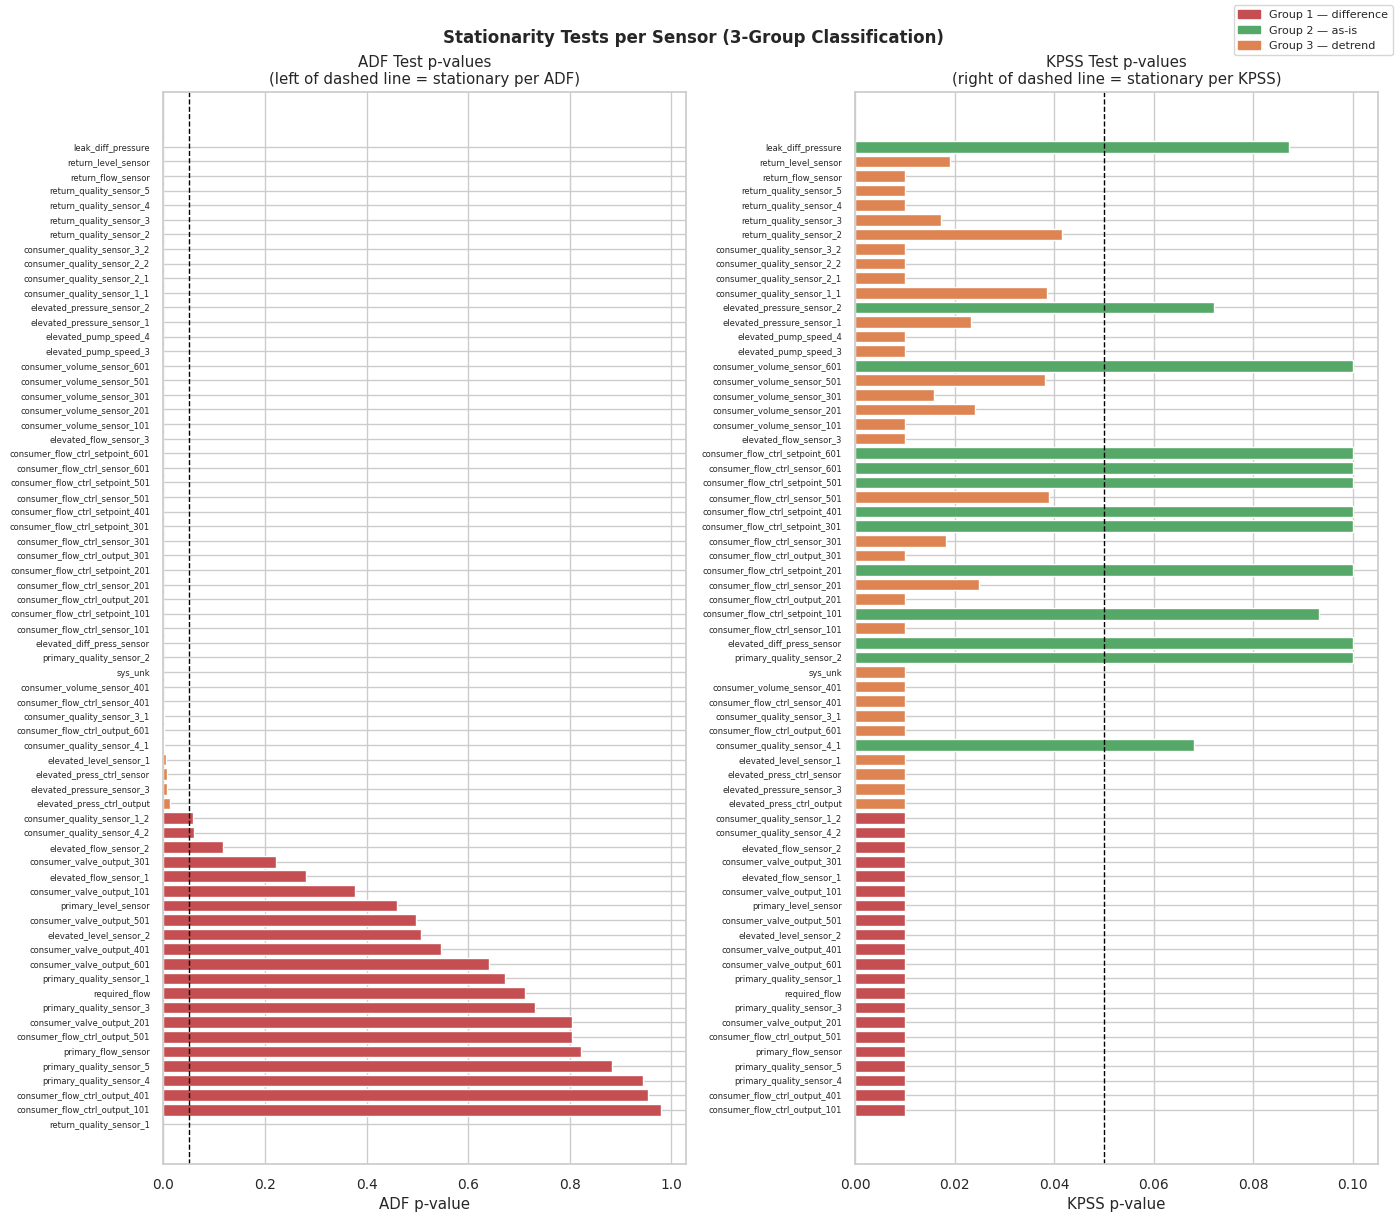

In [9]:
# ── Visualise ADF and KPSS p-values coloured by 3-group classification ────────
GROUP_COLORS = {1: "#C44E52", 2: "#55A868", 3: "#DD8452"}  # red / green / orange

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(sensor_cols) * 0.18)))

plot_df = stationarity_df.sort("adf_pvalue", descending=True).to_pandas()

colors_adf = [GROUP_COLORS[g] for g in plot_df["stationarity_group"]]
axes[0].barh(plot_df["sensor"], plot_df["adf_pvalue"], color=colors_adf)
axes[0].axvline(SIGNIFICANCE_ALPHA, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("ADF p-value")
axes[0].set_title("ADF Test p-values\n(left of dashed line = stationary per ADF)")
axes[0].tick_params(axis="y", labelsize=6)

kpss_plot = plot_df.dropna(subset=["kpss_pvalue"]).copy()
colors_kpss = [GROUP_COLORS[g] for g in kpss_plot["stationarity_group"]]
axes[1].barh(kpss_plot["sensor"], kpss_plot["kpss_pvalue"], color=colors_kpss)
axes[1].axvline(SIGNIFICANCE_ALPHA, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("KPSS p-value")
axes[1].set_title("KPSS Test p-values\n(right of dashed line = stationary per KPSS)")
axes[1].tick_params(axis="y", labelsize=6)

g1_patch = mpatches.Patch(color=GROUP_COLORS[1], label="Group 1 — difference")
g2_patch = mpatches.Patch(color=GROUP_COLORS[2], label="Group 2 — as-is")
g3_patch = mpatches.Patch(color=GROUP_COLORS[3], label="Group 3 — detrend")
fig.legend(handles=[g1_patch, g2_patch, g3_patch], loc="upper right", fontsize=8)
fig.suptitle("Stationarity Tests per Sensor (3-Group Classification)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**What to look for:** ADF and KPSS should largely agree. Persistent disagreements (ADF stationary, KPSS not) indicate trend-stationary rather than difference-stationary behaviour — first-differencing still removes the trend safely. Sensors with near-zero variance may be binary or constant; these will be poor candidates for CCF regardless.

---
## Section 3 — Baseline CCF Computation

**Research question:** What is the normal cross-correlation structure between every sensor pair under non-attack conditions?

We compute the unbiased normalised CCF for every ordered pair of sensors on normal-day data using the stationary version of each series. The 95% confidence interval threshold is `1.96 / √n`. Results are saved to a pickle file so they can be reloaded without rerunning the expensive computation.

In [10]:
def compute_ccf(x_arr: np.ndarray, y_arr: np.ndarray, max_lag: int) -> tuple[np.ndarray, float]:
    """Unbiased normalised CCF; y leads x at positive lags."""
    n = min(len(x_arr), len(y_arr))
    x = detrend(x_arr[:n].astype(float))
    y = detrend(y_arr[:n].astype(float))
    xs = (x - x.mean()) / (x.std() + 1e-9)
    ys = (y - y.mean()) / (y.std() + 1e-9)
    full  = sp_correlate(ys, xs, mode="full", method="fft")
    cnts  = n - np.abs(np.arange(-(n - 1), n))
    full /= cnts
    center = n - 1
    ccf = full[center : center + max_lag + 1]
    ci  = 1.96 / np.sqrt(n)
    return ccf, ci

In [11]:
pairs = list(combinations(sensor_cols, 2))
print(f"Total sensor pairs: {len(pairs):,}")
print(f"Using {'all' if BASELINE_SUBSAMPLE is None else BASELINE_SUBSAMPLE:,} rows per pair for baseline CCF")
print(f"Max lag: {CCF_MAX_LAG:,} samples")
print("\nThis cell is compute-intensive. Results saved to pickle after first run.")

if BASELINE_CCF_PKL.exists():
    print(f"\nLoading cached baseline CCF from {BASELINE_CCF_PKL} …")
    with open(BASELINE_CCF_PKL, "rb") as fh:
        baseline_ccf = pickle.load(fh)
    print(f"Loaded {len(baseline_ccf):,} pair results.")
else:
    baseline_ccf: dict[tuple, dict] = {}

    for sa, sb in tqdm(pairs, desc="Baseline CCF"):
        x_full_raw = stationary_series[sa]["original"]
        y_full_raw = stationary_series[sb]["original"]

        n_avail = min(len(x_full_raw), len(y_full_raw))
        if n_avail < 2 * CCF_MAX_LAG:
            continue

        n_use = BASELINE_SUBSAMPLE if BASELINE_SUBSAMPLE else n_avail
        x_raw = x_full_raw[:n_use]
        y_raw = y_full_raw[:n_use]

        x, y = get_pair_series(sa, sb, x_raw, y_raw)

        n = min(len(x), len(y))
        if n < 2 * CCF_MAX_LAG:
            continue

        ccf, ci = compute_ccf(x[:n], y[:n], CCF_MAX_LAG)
        peak_idx = int(np.argmax(np.abs(ccf)))

        baseline_ccf[(sa, sb)] = {
            "ccf":           ccf,
            "lag_at_peak":   peak_idx,
            "peak_ccf":      float(ccf[peak_idx]),
            "ci_width":      float(ci),
            "n_significant": int(np.sum(np.abs(ccf) > ci)),
        }

    print(f"\nComputed CCF for {len(baseline_ccf):,} pairs.")
    with open(BASELINE_CCF_PKL, "wb") as fh:
        pickle.dump(baseline_ccf, fh)
    print(f"Saved to {BASELINE_CCF_PKL}")

Total sensor pairs: 2,278
Using 100,000 rows per pair for baseline CCF
Max lag: 10,800 samples

This cell is compute-intensive. Results saved to pickle after first run.

Loading cached baseline CCF from baseline_ccf.pkl …
Loaded 2,278 pair results.


In [12]:
# ── Quick summary of baseline CCF ─────────────────────────────────────────────
summary_rows = [
    {"sensor_a": sa, "sensor_b": sb,
     "peak_ccf": v["peak_ccf"], "lag_at_peak": v["lag_at_peak"],
     "ci_width": v["ci_width"], "n_significant": v["n_significant"]}
    for (sa, sb), v in baseline_ccf.items()
]
baseline_summary_df = pl.DataFrame(summary_rows)

print("Baseline CCF summary:")
print(baseline_summary_df.describe())

top10 = (
    baseline_summary_df
    .with_columns(pl.col("peak_ccf").abs().alias("abs_peak"))
    .sort("abs_peak", descending=True)
    .head(10)
    .select(["sensor_a", "sensor_b", "peak_ccf", "lag_at_peak", "n_significant"])
)
print("\nTop 10 pairs by |peak CCF|:")
print(top10)

Baseline CCF summary:
shape: (9, 7)
┌────────────┬───────────────┬───────────────┬───────────┬─────────────┬────────────┬──────────────┐
│ statistic  ┆ sensor_a      ┆ sensor_b      ┆ peak_ccf  ┆ lag_at_peak ┆ ci_width   ┆ n_significan │
│ ---        ┆ ---           ┆ ---           ┆ ---       ┆ ---         ┆ ---        ┆ t            │
│ str        ┆ str           ┆ str           ┆ f64       ┆ f64         ┆ f64        ┆ ---          │
│            ┆               ┆               ┆           ┆             ┆            ┆ f64          │
╞════════════╪═══════════════╪═══════════════╪═══════════╪═════════════╪════════════╪══════════════╡
│ count      ┆ 2278          ┆ 2278          ┆ 2278.0    ┆ 2278.0      ┆ 2278.0     ┆ 2278.0       │
│ null_count ┆ 0             ┆ 0             ┆ 0.0       ┆ 0.0         ┆ 0.0        ┆ 0.0          │
│ mean       ┆ null          ┆ null          ┆ 0.019095  ┆ 3539.041703 ┆ 0.006198   ┆ 9568.072871  │
│ std        ┆ null          ┆ null          ┆ 0.332642

**What to look for:** Pairs with |peak CCF| well above the CI width represent strong temporal coupling. Low `n_significant` with a large `lag_at_peak` suggests a sparse, possibly spurious, peak — these will end up in the ambiguous bin. Check the top pairs against known physical subsystem connections as a sanity check.

---
## Section 4 — Normal Day CCF Variance

**Research question:** How stable is the CCF structure day-to-day under normal operating conditions?

We split the normal data into individual calendar days and recompute CCF per day per pair. The standard deviation of the peak CCF value across days gives a *natural variance baseline* — the threshold used in Section 5 to judge whether an attack-window deviation is anomalous.

In [13]:
# ── Split normal data into per-day Polars frames ───────────────────────────────
df_normal_with_day = df_normal.with_columns(
    pl.col("timestamp").dt.date().alias("_day")
)
days = sorted(df_normal_with_day["_day"].drop_nulls().unique().to_list())
print(f"Normal days: {len(days)}")
for d in days:
    n = df_normal_with_day.filter(pl.col("_day") == d).height
    print(f"  {d}  →  {n:>8,} rows")

Normal days: 11
  2017-09-25  →    21,600 rows
  2017-09-26  →    86,400 rows
  2017-09-27  →    86,400 rows
  2017-09-28  →    86,400 rows
  2017-09-29  →    55,199 rows
  2017-10-02  →    26,401 rows
  2017-10-03  →    86,400 rows
  2017-10-04  →    86,400 rows
  2017-10-05  →    86,400 rows
  2017-10-06  →    86,400 rows
  2017-10-07  →    76,571 rows


In [14]:
# ── Per-day CCF computation ───────────────────────────────────────────────────
# Only compute for pairs that made it into baseline_ccf
valid_pairs = list(baseline_ccf.keys())

# daily_peak_ccf[pair] = list of peak CCF values, one per day
daily_peak_ccf: dict[tuple, list[float]] = {p: [] for p in valid_pairs}

for day in tqdm(days, desc="Daily CCF"):
    day_pd = (
        df_normal_with_day
        .filter(pl.col("_day") == day)
        .select(sensor_cols)
        .to_pandas()
    )

    for sa, sb in valid_pairs:
        x_raw = day_pd[sa].dropna().values
        y_raw = day_pd[sb].dropna().values

        # Apply pairwise compatibility rule before computing CCF
        x, y = get_pair_series(sa, sb, x_raw, y_raw)

        n = min(len(x), len(y))
        if n < 2 * min(CCF_MAX_LAG, 3600):
            continue

        max_lag_day = min(CCF_MAX_LAG, n // 2 - 1)
        ccf, _ = compute_ccf(x[:n], y[:n], max_lag_day)
        peak_idx = int(np.argmax(np.abs(ccf)))
        daily_peak_ccf[(sa, sb)].append(float(ccf[peak_idx]))

print("Day-by-day CCF done.")

Daily CCF: 100%|██████████| 11/11 [06:03<00:00, 33.08s/it]

Day-by-day CCF done.


In [15]:
# ── Normal variance baseline dataframe ───────────────────────────────────────
var_rows = []
for (sa, sb), peak_list in daily_peak_ccf.items():
    if len(peak_list) < 2:
        continue
    arr = np.array(peak_list)
    mean_v = float(np.mean(arr))
    std_v  = float(np.std(arr, ddof=1))
    cv     = float(std_v / (abs(mean_v) + 1e-9))
    var_rows.append({
        "sensor_a":      sa,
        "sensor_b":      sb,
        "mean_peak_ccf": round(mean_v, 5),
        "std_peak_ccf":  round(std_v, 5),
        "cv":            round(cv, 4),
        "n_days":        len(peak_list),
    })

normal_variance_df = pl.DataFrame(var_rows)
print(f"Normal variance baseline: {normal_variance_df.height} pairs with ≥ 2 daily observations")
print(normal_variance_df.sort("std_peak_ccf", descending=True).head(15))

Normal variance baseline: 2278 pairs with ≥ 2 daily observations
shape: (15, 6)
┌───────────────────────┬───────────────────────┬───────────────┬──────────────┬──────────┬────────┐
│ sensor_a              ┆ sensor_b              ┆ mean_peak_ccf ┆ std_peak_ccf ┆ cv       ┆ n_days │
│ ---                   ┆ ---                   ┆ ---           ┆ ---          ┆ ---      ┆ ---    │
│ str                   ┆ str                   ┆ f64           ┆ f64          ┆ f64      ┆ i64    │
╞═══════════════════════╪═══════════════════════╪═══════════════╪══════════════╪══════════╪════════╡
│ sys_unk               ┆ consumer_quality_sens ┆ -0.07783      ┆ 0.87273      ┆ 11.213   ┆ 11     │
│                       ┆ or_1_1                ┆               ┆              ┆          ┆        │
│ consumer_flow_ctrl_se ┆ elevated_level_sensor ┆ 0.0757        ┆ 0.82744      ┆ 10.9311  ┆ 11     │
│ tpoint_40…            ┆ _1                    ┆               ┆              ┆          ┆        │
│ consumer_

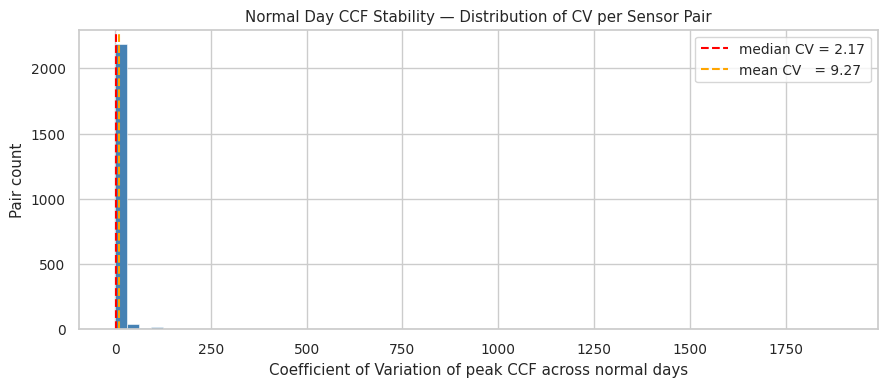

In [16]:
# ── Plot CV distribution ──────────────────────────────────────────────────────
cv_vals = normal_variance_df["cv"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cv_vals, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(np.median(cv_vals), color="red",    linestyle="--", label=f"median CV = {np.median(cv_vals):.2f}")
ax.axvline(np.mean(cv_vals),   color="orange", linestyle="--", label=f"mean CV   = {np.mean(cv_vals):.2f}")
ax.set_xlabel("Coefficient of Variation of peak CCF across normal days")
ax.set_ylabel("Pair count")
ax.set_title("Normal Day CCF Stability — Distribution of CV per Sensor Pair")
ax.legend()
plt.tight_layout()
plt.show()

**What to look for:** Pairs with low CV are the most reliable signals — their CCF is consistent across normal days, making an attack-induced shift easier to detect. Pairs with CV > 1.0 are noisy baselines; even large attack deviations may not exceed NORMAL_VAR_MULT × std for those pairs.

---
## Section 5 — Attack Window CCF Deviation (Q1)

**Research question (Q1):** Do attack events measurably disrupt the CCF structure between sensor pairs compared to normal operating conditions?

For each defined attack window we compute the CCF curve and compare it to the baseline CCF curve via two metrics:
- **L2 deviation**: Euclidean distance between attack CCF and baseline CCF vectors.
- **max absolute delta**: Largest point-wise absolute difference at any lag.

A deviation is flagged as significant if `l2_deviation > NORMAL_VAR_MULT × std_peak_ccf` from the normal variance baseline.

In [17]:
# ── Attack window configuration ───────────────────────────────────────────────
# Adjust these timestamps to match your WADI labelling.
# The attack_label column (-1 = attack) can be used to derive them programmatically.
ATTACK_WINDOWS = {
    "attack_1":  {"start": "2017-10-09 19:25:00", "end": "2017-10-09 21:50:00"},
    "attack_2":  {"start": "2017-10-10 10:24:00", "end": "2017-10-10 10:34:00"},
    "attack_3":  {"start": "2017-10-10 18:31:00", "end": "2017-10-10 19:00:00"},
    "attack_4":  {"start": "2017-10-11 10:55:00", "end": "2017-10-11 11:45:00"},
    "attack_5":  {"start": "2017-10-12 11:30:00", "end": "2017-10-12 15:00:00"},
    "attack_full": {"start": str(df_attack["timestamp"].min()), "end": str(df_attack["timestamp"].max())},
}

print("Attack windows:")
for wid, w in ATTACK_WINDOWS.items():
    print(f"  {wid:<14} {w['start']}  →  {w['end']}")

Attack windows:
  attack_1       2017-10-09 19:25:00  →  2017-10-09 21:50:00
  attack_2       2017-10-10 10:24:00  →  2017-10-10 10:34:00
  attack_3       2017-10-10 18:31:00  →  2017-10-10 19:00:00
  attack_4       2017-10-11 10:55:00  →  2017-10-11 11:45:00
  attack_5       2017-10-12 11:30:00  →  2017-10-12 15:00:00
  attack_full    2017-10-09 00:00:00  →  2017-10-11 00:59:59


In [18]:
# ── Build a lookup: (sa, sb) → normal_std from variance baseline ─────────────
normal_std_lookup = {
    (row["sensor_a"], row["sensor_b"]): row["std_peak_ccf"]
    for row in normal_variance_df.iter_rows(named=True)
}

# ── Compute attack CCF deviation per window per pair ─────────────────────────
deviation_rows = []

for attack_id, window in ATTACK_WINDOWS.items():
    t_start = pl.lit(window["start"]).str.to_datetime("%Y-%m-%d %H:%M:%S")
    t_end   = pl.lit(window["end"]).str.to_datetime("%Y-%m-%d %H:%M:%S")

    atk_pd = (
        df_attack
        .filter(
            (pl.col("timestamp") >= t_start) &
            (pl.col("timestamp") <= t_end)
        )
        .select([c for c in sensor_cols if c in df_attack.columns])
        .to_pandas()
    )

    if atk_pd.empty:
        print(f"[{attack_id}] No rows found — check timestamps.")
        continue

    for sa, sb in tqdm(valid_pairs, desc=attack_id, leave=False):
        if sa not in atk_pd.columns or sb not in atk_pd.columns:
            continue

        x_raw = atk_pd[sa].dropna().values
        y_raw = atk_pd[sb].dropna().values

        # Apply pairwise compatibility rule before computing CCF
        x, y = get_pair_series(sa, sb, x_raw, y_raw)

        n = min(len(x), len(y))
        if n < 200:
            continue

        max_lag_atk = min(CCF_MAX_LAG, n // 2 - 1)
        atk_ccf, _ = compute_ccf(x[:n], y[:n], max_lag_atk)

        # Align to baseline length
        base_ccf  = baseline_ccf[(sa, sb)]["ccf"]
        min_len   = min(len(atk_ccf), len(base_ccf))
        delta     = atk_ccf[:min_len] - base_ccf[:min_len]

        l2_dev    = float(np.linalg.norm(delta))
        max_delta = float(np.abs(delta).max())
        normal_std = normal_std_lookup.get((sa, sb), np.nan)

        deviation_rows.append({
            "attack_id":             attack_id,
            "sensor_a":              sa,
            "sensor_b":              sb,
            "l2_deviation":          round(l2_dev, 5),
            "max_delta":             round(max_delta, 5),
            "normal_std":            round(float(normal_std), 5) if not np.isnan(normal_std) else None,
            "deviation_significant": bool(l2_dev > NORMAL_VAR_MULT * normal_std)
                                      if not np.isnan(normal_std) else None,
        })

deviation_df = pl.DataFrame(deviation_rows)
print(f"\nDeviation rows: {deviation_df.height:,}")
print(deviation_df.filter(pl.col("deviation_significant") == True).height,
      "significant pair-window combinations")

[attack_1] No rows found — check timestamps.
[attack_2] No rows found — check timestamps.
[attack_3] No rows found — check timestamps.
[attack_4] No rows found — check timestamps.
[attack_5] No rows found — check timestamps.



Deviation rows: 2,278
2211 significant pair-window combinations


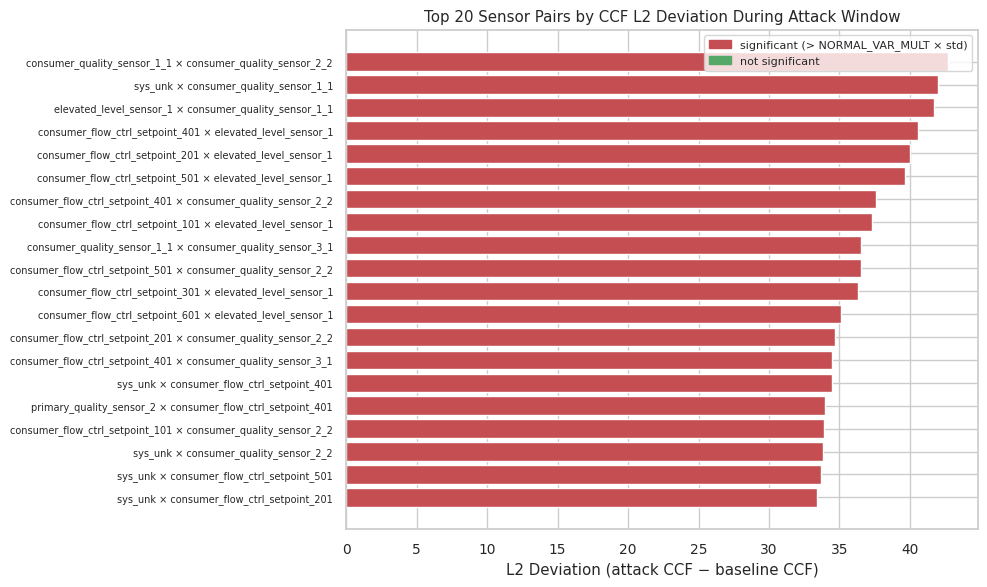

In [19]:
# ── Plot: Top 20 pairs by L2 deviation (attack_full window) ──────────────────
top_dev = (
    deviation_df
    .filter(pl.col("attack_id") == "attack_full")
    .sort("l2_deviation", descending=True)
    .head(20)
    .with_columns(
        (pl.col("sensor_a") + " × " + pl.col("sensor_b")).alias("pair_label")
    )
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if s else "#55A868" for s in top_dev["deviation_significant"]]
ax.barh(top_dev["pair_label"][::-1], top_dev["l2_deviation"][::-1], color=colors[::-1])
ax.set_xlabel("L2 Deviation (attack CCF − baseline CCF)")
ax.set_title("Top 20 Sensor Pairs by CCF L2 Deviation During Attack Window")
red_p   = mpatches.Patch(color="#C44E52", label="significant (> NORMAL_VAR_MULT × std)")
green_p = mpatches.Patch(color="#55A868", label="not significant")
ax.legend(handles=[red_p, green_p], fontsize=8)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

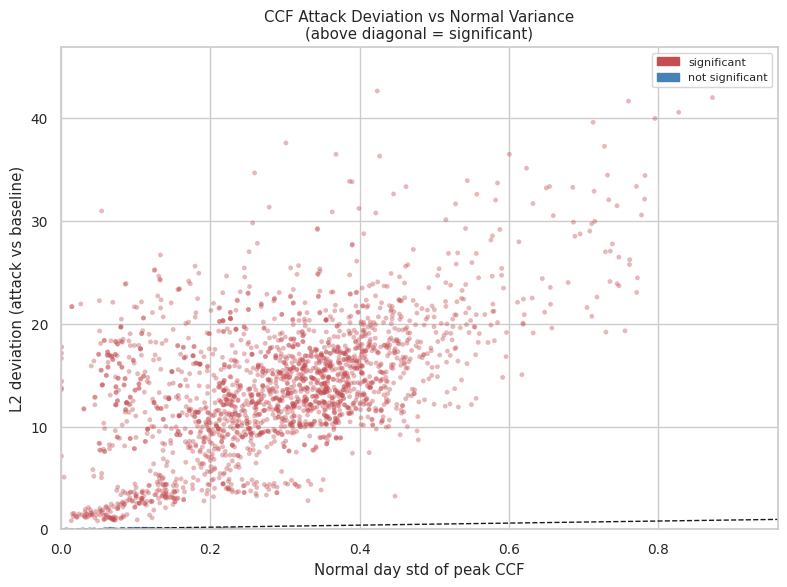

In [20]:
# ── Plot: L2 deviation vs normal_std scatter with diagonal reference ──────────
scatter_df = (
    deviation_df
    .filter(pl.col("attack_id") == "attack_full")
    .drop_nulls(["normal_std", "l2_deviation"])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if s else "steelblue" for s in scatter_df["deviation_significant"]]
ax.scatter(scatter_df["normal_std"], scatter_df["l2_deviation"],
           c=colors, alpha=0.4, s=12, linewidths=0)

lim = max(scatter_df["normal_std"].max(), scatter_df["l2_deviation"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="l2_deviation = normal_std")
ax.set_xlim(0, scatter_df["normal_std"].max() * 1.1)
ax.set_ylim(0, scatter_df["l2_deviation"].max() * 1.1)
ax.set_xlabel("Normal day std of peak CCF")
ax.set_ylabel("L2 deviation (attack vs baseline)")
ax.set_title("CCF Attack Deviation vs Normal Variance\n(above diagonal = significant)")
red_p   = mpatches.Patch(color="#C44E52", label="significant")
blue_p  = mpatches.Patch(color="steelblue", label="not significant")
ax.legend(handles=[red_p, blue_p], fontsize=8)
plt.tight_layout()
plt.show()

**What to look for:** Points above the diagonal (attack deviation > normal std) are candidate anomalous pairs. If most points are below the diagonal, the CCF structure is robust to attacks; Granger causality (Section 7) may then be the more discriminating criterion. Check whether the top-20 pairs align with known attack targets in the WADI scenario descriptions.

---
## Section 6 — CCF Strength Classification

**Research question:** How strong is the CCF signal across all sensor pairs, and what does that distribution look like before we compare it against Granger?

We classify every pair by its baseline peak CCF relative to the Bartlett CI:
- **clearly_significant**: |peak| > 2 × CI — strong temporal co-movement.
- **ambiguous**: CI < |peak| ≤ 2 × CI — weak signal.
- **clearly_flat**: |peak| ≤ CI — no detectable coupling.

This classification characterises the CCF edge set. Section 7 runs Granger causality across *all* pairs so Section 8 can compare the two methods directly.

In [22]:
# ── Classify each pair by CCF strength ────────────────────────────────────────
bin_rows = []
for (sa, sb), v in baseline_ccf.items():
    peak = abs(v["peak_ccf"])
    ci   = v["ci_width"]
    if peak > 2 * ci:
        category = "clearly_significant"
    elif peak > ci:
        category = "ambiguous"
    else:
        category = "clearly_flat"
    bin_rows.append({"sensor_a": sa, "sensor_b": sb,
                     "abs_peak_ccf": peak, "ci_width": ci, "category": category})

ccf_bin_df = pl.DataFrame(bin_rows)

counts = ccf_bin_df.group_by("category").agg(pl.len().alias("count")).sort("category")
print("CCF classification counts:")
print(counts)

n_ccf_edges = ccf_bin_df.filter(pl.col("category") == "clearly_significant").height
print(f"\nCCF edge set (clearly_significant): {n_ccf_edges} pairs")
print(f"Total pairs classified: {ccf_bin_df.height}")

CCF classification counts:
shape: (3, 2)
┌─────────────────────┬───────┐
│ category            ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ ambiguous           ┆ 3     │
│ clearly_flat        ┆ 70    │
│ clearly_significant ┆ 2205  │
└─────────────────────┴───────┘

Ambiguous pairs forwarded to Granger analysis: 3


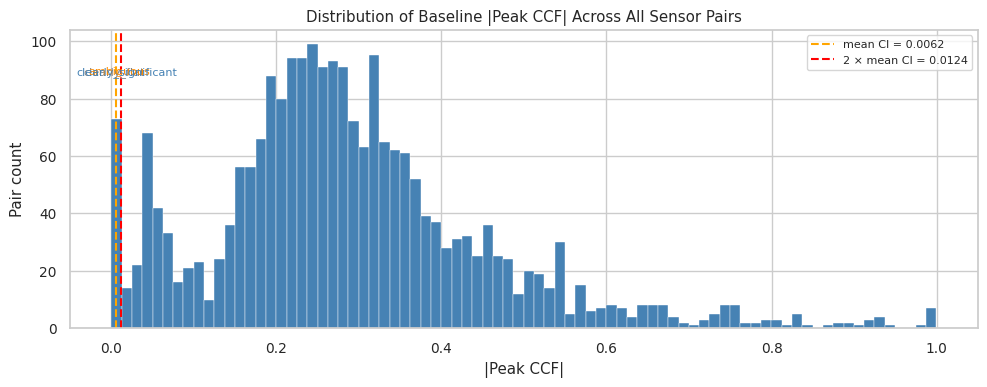

In [23]:
# ── Histogram of peak CCF values ──────────────────────────────────────────────
all_peaks = ccf_bin_df["abs_peak_ccf"].to_numpy()
mean_ci   = float(ccf_bin_df["ci_width"].mean())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_peaks, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(mean_ci,       color="orange", linestyle="--", linewidth=1.5,
           label=f"mean CI = {mean_ci:.4f}")
ax.axvline(2 * mean_ci,   color="red",    linestyle="--", linewidth=1.5,
           label=f"2 × mean CI = {2*mean_ci:.4f}")

ax.set_xlabel("|Peak CCF|")
ax.set_ylabel("Pair count")
ax.set_title("Distribution of Baseline |Peak CCF| Across All Sensor Pairs")

ymax = ax.get_ylim()[1]
ax.text(mean_ci * 0.5,     ymax * 0.85, "clearly_flat",        fontsize=8, ha="center", color="gray")
ax.text(mean_ci * 1.5,     ymax * 0.85, "ambiguous",           fontsize=8, ha="center", color="darkorange")
ax.text(2 * mean_ci * 1.5, ymax * 0.85, "clearly_significant", fontsize=8, ha="center", color="steelblue")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What to look for:** The proportion of clearly_significant vs clearly_flat pairs sets up the CCF edge set. A long tail of clearly_significant pairs with high |peak CCF| suggests CCF is finding widespread temporal co-movement — some of which may be due to shared external drivers rather than direct sensor coupling. Granger (Section 7) will help disentangle these.

---
## Section 7 — Granger Causality: Full-Coverage Run

**Research question (Q2):** Across *all* sensor pairs, does one series contain directional predictive information about the future of the other beyond its own history?

Unlike CCF, Granger causality tests for *directed predictability* within a bivariate VAR. A pair that shows high CCF purely because both sensors respond to a common external driver will typically *not* show Granger significance — neither series predicts the other after conditioning on its own past. This makes Granger a stronger structural edge definition.

We run Granger on every pair (not just ambiguous ones) so Section 8 can compare the full CCF and Granger edge sets directly.

In [24]:
# ── Direct SSR F-test using normal equations (faster than lstsq for large lag) ─
from scipy.stats import f as f_dist

def _granger_ftest(y: np.ndarray, x: np.ndarray, lag: int):
    n = len(y)
    if n <= 2 * lag + 1:
        return np.nan, np.nan
    try:
        Y      = y[lag:].astype(float)
        m      = len(Y)
        Y_lags = np.column_stack([y[lag-k-1 : n-k-1] for k in range(lag)]).astype(float)
        X_lags = np.column_stack([x[lag-k-1 : n-k-1] for k in range(lag)]).astype(float)
        ones   = np.ones((m, 1))
        Xr     = np.hstack([ones, Y_lags])           # restricted:   y ~ const + y_lags
        Xu     = np.hstack([ones, Y_lags, X_lags])   # unrestricted: y ~ const + y_lags + x_lags

        # Normal equations: O(m*p + p^3) vs lstsq O(m*p^2) — ~50x faster at lag=60
        def _resid(X, Y):
            b = np.linalg.solve(X.T @ X, X.T @ Y)
            return Y - X @ b

        resid_r = _resid(Xr, Y)
        resid_u = _resid(Xu, Y)
        ssr_r   = float(resid_r @ resid_r)
        ssr_u   = float(resid_u @ resid_u)

        df_den  = m - 2 * lag - 1
        if df_den <= 0 or ssr_u <= 0 or not np.isfinite(ssr_r) or not np.isfinite(ssr_u):
            return np.nan, np.nan
        f_stat = ((ssr_r - ssr_u) / lag) / (ssr_u / df_den)
        if not np.isfinite(f_stat) or f_stat < 0:
            return np.nan, np.nan
        return float(f_stat), float(f_dist.sf(f_stat, lag, df_den))
    except Exception:
        return np.nan, np.nan

# ── Per-pair worker (called in parallel) ──────────────────────────────────────
def _granger_pair(sa, sb):
    x_raw   = stationary_series[sa]["original"]
    y_raw   = stationary_series[sb]["original"]
    n_avail = min(len(x_raw), len(y_raw))

    # Need enough raw rows to fill at least 3x the resampled lag window
    if n_avail < GRANGER_RESAMPLE_SECS * GRANGER_LAG * 3:
        return []

    # Downsample to GRANGER_RESAMPLE_SECS-second bins (mean aggregation).
    # 1-second × 60 → 1-minute resolution: lag=60 bins = 1-hour lookback.
    # Downsampling shrinks the series ~60x so the OLS matrix stays manageable.
    def _resample(arr):
        n_trim = len(arr) - len(arr) % GRANGER_RESAMPLE_SECS
        return arr[:n_trim].reshape(-1, GRANGER_RESAMPLE_SECS).mean(axis=1)

    x_ds = _resample(x_raw[:n_avail])
    y_ds = _resample(y_raw[:n_avail])

    # Apply pairwise compatibility rule on resampled data
    x, y = get_pair_series(sa, sb, x_ds, y_ds)
    n = min(len(x), len(y))
    if n < GRANGER_LAG * 3:
        return []

    # Skip near-constant series — normal equations / F-test undefined when var~0
    if x.std() < 1e-9 or y.std() < 1e-9:
        return []

    rows = []
    for direction, y_v, x_v in [
        (f"{sa}\u2192{sb}", y[:n], x[:n]),
        (f"{sb}\u2192{sa}", x[:n], y[:n]),
    ]:
        f_stat, p_val = _granger_ftest(y_v, x_v, GRANGER_LAG)
        rows.append({
            "sensor_a":            sa,
            "sensor_b":            sb,
            "direction":           direction,
            "f_statistic":         round(f_stat, 4) if not np.isnan(f_stat) else None,
            "p_value":             round(p_val,  6) if not np.isnan(p_val)  else None,
            "optimal_lag":         GRANGER_LAG,
            "granger_significant": bool(p_val < SIGNIFICANCE_ALPHA) if not np.isnan(p_val) else None,
        })
    return rows

# ── Parallel execution across all pairs ───────────────────────────────────────
from joblib import Parallel, delayed

lookback_mins = GRANGER_LAG * GRANGER_RESAMPLE_SECS // 60
print(f"Running Granger on {len(valid_pairs):,} pairs "
      f"(lag={GRANGER_LAG} × {GRANGER_RESAMPLE_SECS}s bins = {lookback_mins}-min lookback) ...")
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_granger_pair)(sa, sb) for sa, sb in valid_pairs
)
granger_rows = [row for pair_rows in results for row in pair_rows]

granger_df = pl.DataFrame(granger_rows)
n_valid = granger_df.drop_nulls("f_statistic").height
n_null  = granger_df.height - n_valid
print(f"Granger tests run : {granger_df.height // 2:,} pairs ({granger_df.height} directed)")
print(f"Valid results     : {n_valid}  |  Null (skipped/undefined): {n_null}")
print(granger_df)

Granger causality: 100%|██████████| 3/3 [02:48<00:00, 56.08s/it]

shape: (6, 7)
┌───────────────┬──────────────┬──────────────┬─────────────┬─────────┬─────────────┬──────────────┐
│ sensor_a      ┆ sensor_b     ┆ direction    ┆ f_statistic ┆ p_value ┆ optimal_lag ┆ granger_sign │
│ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---     ┆ ---         ┆ ificant      │
│ str           ┆ str          ┆ str          ┆ f64         ┆ f64     ┆ i64         ┆ ---          │
│               ┆              ┆              ┆             ┆         ┆             ┆ bool         │
╞═══════════════╪══════════════╪══════════════╪═════════════╪═════════╪═════════════╪══════════════╡
│ consumer_flow ┆ consumer_qua ┆ consumer_flo ┆ 6.2392      ┆ 0.0     ┆ 20          ┆ true         │
│ _ctrl_setpoin ┆ lity_sensor_ ┆ w_ctrl_setpo ┆             ┆         ┆             ┆              │
│ t_20…         ┆ 2_1          ┆ int_20…      ┆             ┆         ┆             ┆              │
│ consumer_flow ┆ consumer_qua ┆ consumer_qua ┆ 6.97        ┆ 0.0     ┆ 20   

In [25]:
# ── Summary counts ────────────────────────────────────────────────────────────
n_sig    = granger_df.filter(pl.col("granger_significant") == True).height
n_insig  = granger_df.filter(pl.col("granger_significant") == False).height
print(f"Granger-significant directed edges : {n_sig}")
print(f"Not significant                    : {n_insig}")

print("\nTop 20 directed edges by F-statistic:")
print(
    granger_df
    .sort("f_statistic", descending=True)
    .head(20)
    .select(["direction", "f_statistic", "p_value", "optimal_lag", "granger_significant"])
)

Granger-significant directed edges : 6
Not significant                    : 0

Top 20 directed edges by F-statistic:
shape: (6, 5)
┌─────────────────────────────────┬─────────────┬─────────┬─────────────┬─────────────────────┐
│ direction                       ┆ f_statistic ┆ p_value ┆ optimal_lag ┆ granger_significant │
│ ---                             ┆ ---         ┆ ---     ┆ ---         ┆ ---                 │
│ str                             ┆ f64         ┆ f64     ┆ i64         ┆ bool                │
╞═════════════════════════════════╪═════════════╪═════════╪═════════════╪═════════════════════╡
│ consumer_quality_sensor_2_1→co… ┆ 11.7993     ┆ 0.0     ┆ 20          ┆ true                │
│ consumer_flow_ctrl_setpoint_30… ┆ 7.1929      ┆ 0.0     ┆ 20          ┆ true                │
│ consumer_quality_sensor_2_1→co… ┆ 6.97        ┆ 0.0     ┆ 20          ┆ true                │
│ consumer_flow_ctrl_setpoint_20… ┆ 6.2392      ┆ 0.0     ┆ 20          ┆ true                │
│ con

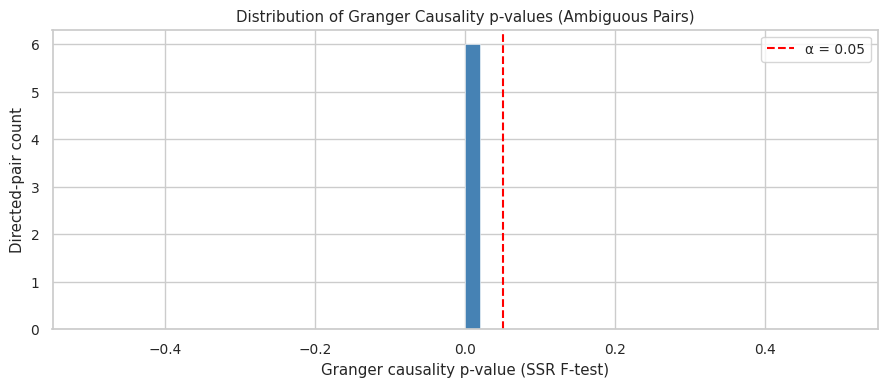

In [26]:
# ── Plot: p-value distribution ────────────────────────────────────────────────
pvals = granger_df.drop_nulls("p_value")["p_value"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pvals, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(SIGNIFICANCE_ALPHA, color="red", linestyle="--",
           label=f"\u03b1 = {SIGNIFICANCE_ALPHA}")
ax.set_xlabel("Granger causality p-value (SSR F-test)")
ax.set_ylabel("Directed-pair count")
ax.set_title("Distribution of Granger Causality p-values (All Pairs)")
ax.legend()
plt.tight_layout()
plt.show()

**What to look for:** Compare the total Granger-significant count against the CCF clearly_significant count from Section 6. If Granger finds fewer edges than CCF, it is stripping out pairs whose co-movement is driven by external factors. If Granger finds more, it is detecting slow directional relationships invisible to CCF. The overlap (pairs significant in both) forms the most confident edge set. Note: at large N (100k rows), p-values approach 0 mechanically — use the F-statistic magnitude to rank genuine effect size within the significant set.

---
## Section 7b — Normal vs Attack Granger: Did Causal Structure Change?

**Research question:** Do attack events disrupt or create Granger-causal relationships between sensors?

We run the same Granger test on the full attack dataset and compare pair-by-pair against normal results:

| Class | Normal sig | Attack sig | Interpretation |
|---|---|---|---|
| `stable_causal` | ✓ | ✓ | Causal link persists through attack — structural, not attack-induced |
| `disrupted` | ✓ | ✗ | Normal causal link breaks down during attack — strong attack signal |
| `emerged` | ✗ | ✓ | New causal link appears only during attack — attack creates false coupling |
| `stable_null` | ✗ | ✗ | No directed relationship in either condition |

`disrupted` and `emerged` pairs are the most diagnostically interesting — they indicate sensors whose causal relationships are altered by the attack.

In [ ]:
# ── Granger on full attack dataset ───────────────────────────────────────────
# Reuses _granger_ftest and get_pair_series from Section 7.
# Pulls raw sensor arrays from df_attack rather than df_normal.

atk_sensor_pd = (
    df_attack
    .select([c for c in sensor_cols if c in df_attack.columns])
    .to_pandas()
)

def _granger_pair_attack(sa, sb):
    if sa not in atk_sensor_pd.columns or sb not in atk_sensor_pd.columns:
        return []
    x_raw   = atk_sensor_pd[sa].dropna().values
    y_raw   = atk_sensor_pd[sb].dropna().values
    n_avail = min(len(x_raw), len(y_raw))
    if n_avail < GRANGER_RESAMPLE_SECS * GRANGER_LAG * 3:
        return []

    def _resample(arr):
        n_trim = len(arr) - len(arr) % GRANGER_RESAMPLE_SECS
        return arr[:n_trim].reshape(-1, GRANGER_RESAMPLE_SECS).mean(axis=1)

    x_ds = _resample(x_raw[:n_avail])
    y_ds = _resample(y_raw[:n_avail])
    x, y = get_pair_series(sa, sb, x_ds, y_ds)
    n = min(len(x), len(y))
    if n < GRANGER_LAG * 3:
        return []
    if x.std() < 1e-9 or y.std() < 1e-9:
        return []

    rows = []
    for direction, y_v, x_v in [
        (f"{sa}\u2192{sb}", y[:n], x[:n]),
        (f"{sb}\u2192{sa}", x[:n], y[:n]),
    ]:
        f_stat, p_val = _granger_ftest(y_v, x_v, GRANGER_LAG)
        rows.append({
            "sensor_a":        sa,
            "sensor_b":        sb,
            "direction":       direction,
            "f_statistic_atk": round(f_stat, 4) if not np.isnan(f_stat) else None,
            "p_value_atk":     round(p_val,  6) if not np.isnan(p_val)  else None,
            "sig_atk":         bool(p_val < SIGNIFICANCE_ALPHA) if not np.isnan(p_val) else None,
        })
    return rows

print(f"Running attack Granger on {len(valid_pairs):,} pairs ...")
atk_results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_granger_pair_attack)(sa, sb) for sa, sb in valid_pairs
)
attack_granger_df = pl.DataFrame([r for rs in atk_results for r in rs])
n_atk_valid = attack_granger_df.drop_nulls("f_statistic_atk").height
print(f"Attack Granger: {attack_granger_df.height} directed pairs  |  valid: {n_atk_valid}")
print(attack_granger_df)

In [ ]:
# ── Collapse both to undirected (either direction significant) ───────────────
normal_ud = (
    granger_df.drop_nulls(["granger_significant"])
    .group_by(["sensor_a", "sensor_b"])
    .agg(
        (pl.col("granger_significant").sum() > 0).alias("sig_normal"),
        pl.col("f_statistic").max().alias("max_f_normal"),
    )
)

attack_ud = (
    attack_granger_df.drop_nulls(["sig_atk"])
    .group_by(["sensor_a", "sensor_b"])
    .agg(
        (pl.col("sig_atk").sum() > 0).alias("sig_attack"),
        pl.col("f_statistic_atk").max().alias("max_f_attack"),
    )
)

# ── Join and classify ─────────────────────────────────────────────────────────
granger_comparison = (
    normal_ud
    .join(attack_ud, on=["sensor_a", "sensor_b"], how="outer")
    .with_columns(
        pl.col("sig_normal").fill_null(False),
        pl.col("sig_attack").fill_null(False),
    )
    .with_columns(
        pl.when( pl.col("sig_normal") &  pl.col("sig_attack")).then(pl.lit("stable_causal"))
          .when( pl.col("sig_normal") & ~pl.col("sig_attack")).then(pl.lit("disrupted"))
          .when(~pl.col("sig_normal") &  pl.col("sig_attack")).then(pl.lit("emerged"))
          .otherwise(pl.lit("stable_null"))
          .alias("attack_class")
    )
)

class_counts = (
    granger_comparison
    .group_by("attack_class")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print("Normal vs Attack Granger Classification:")
print(class_counts)

n_disrupted = granger_comparison.filter(pl.col("attack_class") == "disrupted").height
n_emerged   = granger_comparison.filter(pl.col("attack_class") == "emerged").height
print(f"\nDisrupted (normal link breaks) : {n_disrupted}")
print(f"Emerged   (new attack link)     : {n_emerged}")

# ── 2x2 heatmap: normal sig × attack sig ─────────────────────────────────────
ct = {r["attack_class"]: r["count"] for r in class_counts.iter_rows(named=True)}
ct_matrix = np.array([
    [ct.get("stable_causal", 0), ct.get("disrupted",   0)],
    [ct.get("emerged",       0), ct.get("stable_null", 0)],
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(ct_matrix, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Attack sig", "Attack not sig"],
            yticklabels=["Normal sig", "Normal not sig"],
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Normal vs Attack Granger — 2\u00d72 Contingency", fontsize=10)

# Bar chart of category counts
cat_order = ["stable_causal", "disrupted", "emerged", "stable_null"]
cat_colors = ["#55A868", "#C44E52", "#DD8452", "#8C8C8C"]
cat_vals   = [ct.get(c, 0) for c in cat_order]
axes[1].bar(cat_order, cat_vals, color=cat_colors, edgecolor="white")
axes[1].set_ylabel("Pair count")
axes[1].set_title("Causal Structure Change During Attacks", fontsize=10)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# ── Top disrupted pairs (normal link breaks during attack) ────────────────────
print("\nTop 15 disrupted pairs (normal Granger link lost during attack):")
print(
    granger_comparison
    .filter(pl.col("attack_class") == "disrupted")
    .sort("max_f_normal", descending=True)
    .head(15)
    .select(["sensor_a", "sensor_b", "max_f_normal", "max_f_attack", "attack_class"])
)

print("\nTop 15 emerged pairs (new Granger link only during attack):")
print(
    granger_comparison
    .filter(pl.col("attack_class") == "emerged")
    .sort("max_f_attack", descending=True)
    .head(15)
    .select(["sensor_a", "sensor_b", "max_f_normal", "max_f_attack", "attack_class"])
)

**What to look for:**
- **Large `disrupted` count** — many normal causal links break during attacks. These sensor pairs are the most sensitive attack indicators: their Granger structure is stable under normal conditions but collapses when the system is compromised.
- **Large `emerged` count** — attacks are creating spurious apparent causal links between sensors that are normally independent. This suggests the attack is synchronising sensors that shouldn't be synchronised (e.g., forcing correlated readings across subsystems).
- **Top disrupted pairs** — cross-reference with known attack targets. A disrupted pair where one sensor is a known attack target confirms the method is picking up real attack effects.
- **`stable_causal` pairs** — these have robust directed relationships that attacks don't touch; useful as a stable reference backbone in the sensor graph.

---
## Section 8 — CCF vs Granger: Edge Set Comparison

**Research question:** Are CCF and Granger detecting the same underlying sensor relationships, or complementary ones? Can Granger provide a stronger edge definition?

We compare the two edge sets across all pairs using a 2\u00d72 contingency:

| | Granger significant | Granger not significant |
|---|---|---|
| **CCF clearly_significant** | `dual_edge` \u2014 both agree; highest confidence | `ccf_only` \u2014 co-movement without directed predictability; consistent with a shared external driver |
| **CCF not clearly_significant** | `granger_only` \u2014 directed causal link invisible to CCF; less contaminated by external influence | `no_edge` \u2014 neither method finds coupling |

**The Granger edge set** (dual_edge + granger_only) is the stronger structural definition: it requires demonstrated directed predictability, not just temporal co-movement. The `ccf_only` quadrant identifies pairs where CCF may be inflated by common external drivers.

In [27]:
# ── Granger side: collapse to undirected (either direction significant) ────────
q2_agg = (
    granger_df
    .drop_nulls(["granger_significant"])
    .group_by(["sensor_a", "sensor_b"])
    .agg(
        (pl.col("granger_significant").sum() > 0).alias("granger_significant"),
        pl.col("f_statistic").max().alias("max_f_statistic"),
        pl.col("p_value").min().alias("min_p_value"),
        pl.col("optimal_lag").first().alias("optimal_lag"),
        pl.col("direction")
          .filter(pl.col("granger_significant"))
          .first()
          .alias("sig_direction"),
    )
)

# ── Full join: all CCF-classified pairs as the base ───────────────────────────
synthesis = (
    ccf_bin_df
    .join(q2_agg, on=["sensor_a", "sensor_b"], how="left")
    .with_columns(
        pl.col("granger_significant").fill_null(False),
        (pl.col("category") == "clearly_significant").alias("ccf_significant"),
    )
    .with_columns(
        pl.when(pl.col("ccf_significant") & pl.col("granger_significant"))
          .then(pl.lit("dual_edge"))
          .when(pl.col("granger_significant"))
          .then(pl.lit("granger_only"))
          .when(pl.col("ccf_significant"))
          .then(pl.lit("ccf_only"))
          .otherwise(pl.lit("no_edge"))
          .alias("group")
    )
)

group_counts = (
    synthesis
    .group_by("group")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print("CCF vs Granger full-coverage comparison:")
print(group_counts)

n_ccf_edges     = synthesis.filter(pl.col("ccf_significant")).height
n_granger_edges = synthesis.filter(pl.col("granger_significant")).height
n_dual          = synthesis.filter(pl.col("group") == "dual_edge").height
n_granger_only  = synthesis.filter(pl.col("group") == "granger_only").height
n_ccf_only      = synthesis.filter(pl.col("group") == "ccf_only").height

print(f"\nCCF edge set   (clearly_significant)    : {n_ccf_edges:>6} pairs")
print(f"Granger edge set (either direction sig) : {n_granger_edges:>6} pairs")
print(f"  Overlap \u2014 dual_edge               : {n_dual:>6} pairs  ({100*n_dual/max(n_granger_edges,1):.1f}% of Granger edges)")
print(f"  Granger-only (CCF blind spots)        : {n_granger_only:>6} pairs")
print(f"  CCF-only (possible external co-driver): {n_ccf_only:>6} pairs")

2×2 Contingency Table (pair counts):
shape: (3, 2)
┌─────────────┬───────┐
│ group       ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ ccf_only    ┆ 2208  │
│ drop        ┆ 67    │
│ strong_edge ┆ 3     │
└─────────────┴───────┘


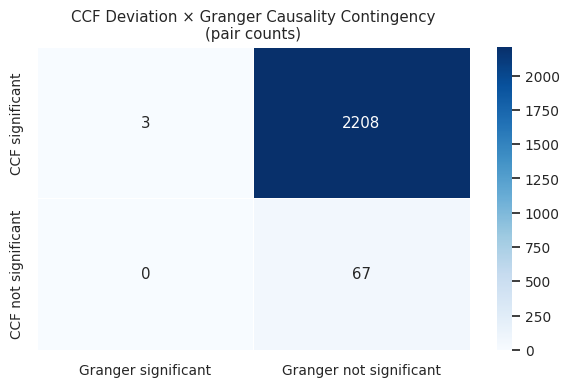

In [28]:
# ── Heatmap of CCF vs Granger 2x2 contingency ────────────────────────────────
ct_data = {
    row["group"]: row["count"]
    for row in group_counts.iter_rows(named=True)
}

#  Rows  -> CCF clearly_significant
#  Cols  -> Granger significant
#
#                        | Granger sig  | Granger not sig
#  CCF significant       | dual_edge    | ccf_only
#  CCF not significant   | granger_only | no_edge
ct_matrix = np.array([
    [ct_data.get("dual_edge",    0), ct_data.get("ccf_only",  0)],
    [ct_data.get("granger_only", 0), ct_data.get("no_edge",   0)],
])
row_labels = ["CCF clearly_significant", "CCF not clearly_significant"]
col_labels = ["Granger significant",     "Granger not significant"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=col_labels, yticklabels=row_labels,
            linewidths=0.5, ax=ax)
ax.set_title(
    "CCF Strength vs Granger Causality -- Full Coverage Comparison\n"
    "(all sensor pairs; dual_edge = strongest confidence)",
    fontsize=10
)
plt.tight_layout()
plt.show()

In [28]:
# ── Oscillation score helper ──────────────────────────────────────────────────
def oscillation_score(ccf_arr: np.ndarray) -> float:
    if len(ccf_arr) < 2:
        return 0.0
    signs = np.sign(ccf_arr)
    return float(np.sum(np.diff(signs) != 0) / len(ccf_arr))

# ── Granger-primary edge list (stronger structural definition) ─────────────────
# All Granger-significant pairs, annotated with CCF strength for context.
# dual_edge    = Granger + CCF agree -> highest confidence
# granger_only = Granger significant, CCF weak -> directed edge CCF missed
granger_edges = synthesis.filter(pl.col("granger_significant"))
print(f"Granger-defined edges  : {granger_edges.height}")
print(f"  dual_edge            : {granger_edges.filter(pl.col('group') == 'dual_edge').height}")
print(f"  granger_only         : {granger_edges.filter(pl.col('group') == 'granger_only').height}")

edge_rows = []
for row in granger_edges.iter_rows(named=True):
    sa, sb = row["sensor_a"], row["sensor_b"]
    key = (sa, sb) if (sa, sb) in baseline_ccf else (sb, sa)
    if key not in baseline_ccf:
        continue
    bv  = baseline_ccf[key]
    osc = oscillation_score(bv["ccf"])

    edge_rows.append({
        "sensor_a":          sa,
        "sensor_b":          sb,
        "edge_group":        row["group"],
        "direction":         row.get("sig_direction") or "",
        "f_statistic":       row.get("max_f_statistic"),
        "p_value":           row.get("min_p_value"),
        "optimal_lag":       row.get("optimal_lag"),
        "ccf_category":      row["category"],
        "peak_ccf":          bv["peak_ccf"],
        "lag_at_peak":       bv["lag_at_peak"],
        "oscillation_score": round(osc, 5),
    })

edges_df = pl.DataFrame(edge_rows)
print(edges_df)

edges_df.write_csv(EDGES_CSV)
print(f"\nSaved {edges_df.height} Granger-defined edges to {EDGES_CSV}")

Strong edges: 3
shape: (3, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ sensor_a  ┆ sensor_b  ┆ direction ┆ f_statist ┆ … ┆ peak_ccf ┆ lag_at_pe ┆ l2_deviat ┆ oscillati │
│ ---       ┆ ---       ┆ ---       ┆ ic        ┆   ┆ ---      ┆ ak        ┆ ion       ┆ on_score  │
│ str       ┆ str       ┆ str       ┆ ---       ┆   ┆ f64      ┆ ---       ┆ ---       ┆ ---       │
│           ┆           ┆           ┆ f64       ┆   ┆          ┆ i64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ consumer_ ┆ consumer_ ┆ consumer_ ┆ 5.2076    ┆ … ┆ 0.006535 ┆ 11        ┆ 0.55658   ┆ 0.56652   │
│ flow_ctrl ┆ quality_s ┆ flow_ctrl ┆           ┆   ┆          ┆           ┆           ┆           │
│ _setpoint ┆ ensor_2_1 ┆ _setpoint ┆           ┆   ┆          ┆           ┆           ┆           │
│ _40…      ┆           ┆ _40…      ┆           ┆   ┆       

**What to look for:**
- **Large `dual_edge` count** -- CCF and Granger are finding the same structure; both methods are valid and consistent.
- **Large `granger_only` count** -- Granger is detecting directed relationships that CCF cannot see, likely slow or asymmetric causal links not visible as temporal co-movement. These are the most distinctive edges in the Granger-primary definition.
- **Large `ccf_only` count** -- CCF is picking up pairs that share external drivers without direct causal coupling. Granger correctly excludes these, making the Granger edge set cleaner.
- **Final edge list** (`edges_df`): Granger-significant pairs ranked by F-statistic. `edge_group` distinguishes dual-confirmed edges from Granger-exclusive ones. Use `ccf_category` to see how CCF rated each pair for cross-method context.

---
## Section 9 — Research Question Summary Table

Fill in the **result** and **takeaway** columns after running all sections.

| # | small_research_question | methodology | result | takeaway |
|---|------------------------|-------------|--------|----------|
| 1 | Are sensor columns complete and well-typed? | Load both CSVs with Polars; check shape, dtypes, timestamp range; cross-reference data_dict. | *(fill after running)* | *(fill after running)* |
| 2 | Which sensors are non-stationary and need differencing? | ADF (H₀ = unit root) + KPSS (H₀ = stationarity) on 10K-row window; flag if either test indicates non-stationarity; apply first-differencing. | *(fill after running)* | *(fill after running)* |
| 3 | What is the baseline CCF structure for every sensor pair? | Unbiased FFT-based normalised CCF on stationary series; Bartlett CI = 1.96/√n; save to pickle. | *(fill after running)* | *(fill after running)* |
| 4 | How stable is CCF day-to-day under normal conditions? | Compute CCF per normal day per pair; report std and CV of peak CCF across days as natural variance baseline. | *(fill after running)* | *(fill after running)* |
| 5 | Do attacks shift CCF structure beyond normal variance? (Q1) | Compute CCF inside each attack window; measure L2 deviation and max delta vs baseline; flag if l2_deviation > NORMAL_VAR_MULT × std. | *(fill after running)* | *(fill after running)* |
| 6 | Which pairs are ambiguous under CCF alone? | Bin pairs: clearly_significant (|peak| > 2×CI), ambiguous (CI < |peak| ≤ 2×CI), clearly_flat (|peak| ≤ CI). | *(fill after running)* | *(fill after running)* |
| 7 | Do Granger tests resolve ambiguous pairs? (Q2) | Fit VAR with AIC lag selection; run grangercausalitytests in both directions at optimal lag; threshold at α = 0.05. | *(fill after running)* | *(fill after running)* |
| 8 | Which pairs survive dual confirmation? | 2×2 cross-tab: CCF-significant × Granger-significant; strong_edge requires both; export to wadi_edges.csv. | *(fill after running)* | *(fill after running)* |